In [1]:
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import suncalc

import dask.dataframe as dd
from pathlib import Path
import glob
import re

import datetime as dt
import pytz

import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches
from matplotlib.lines import Line2D

In [2]:
import sys

sys.path.append("../src")
sys.path.append("../src/bout")
sys.path.append("../src/tests")

In [3]:
import activity.subsampling as ss
import comparison.data_assembly as comp
from core import SITE_NAMES

from cli import get_file_paths

In [4]:
def get_percent_points_in_bounds_log(plt_dcmetr, plt_cmetr, p, upb):
    points_dc = pd.DataFrame(plt_dcmetr.values, columns=['values'], index=plt_dcmetr.index)
    points_c = pd.DataFrame(plt_cmetr.values, columns=['values'], index=plt_cmetr.index)
    points_c = points_c[points_c!=0].dropna()
    points_dc = points_dc.loc[points_c.index]
    total_num_points = points_dc.shape[0]

    axis = 1
    within_bounds = ((points_dc.values<=points_c.values*(axis+(upb*p)))&(points_dc.values>=points_c.values*(axis-p)))
    num_points_in_bounds = np.sum(within_bounds.astype(int), axis=0)
    percent_points_in_bounds = num_points_in_bounds / total_num_points
    all_points_bound = p[percent_points_in_bounds==1][0]

    test_true_100_at_factor(points_dc, points_c, all_points_bound)

    return percent_points_in_bounds

def test_true_100_at_factor(points_dc, points_c, p):
    test_dc = points_dc[points_dc!=0].dropna()
    test_c = points_c.loc[test_dc.index]
    filt_dc = (test_dc.values>test_c.values*(1+p))|(test_dc.values<test_c.values*(1-p))
    assert filt_dc.all()==False

def plot_variance_of_points_log(plt_dcmetr, plt_cmetr, data_params): 
    dc_tag_split = re.findall(r"\d+", plt_dcmetr.columns[0])
    total = int(dc_tag_split[-1])
    on = int(dc_tag_split[0])
    listening_ratio = on/total
    dctag1 = re.search(r"\d+of\d+", plt_dcmetr.columns[0])[0]
    upper_bound_line = (1/listening_ratio)-1
    if data_params['upb']!=1:
        upb = upper_bound_line
    else:
        upb = data_params['upb']
    zero_bound_points = 1.0

    p = np.arange(0, 6, 0.01) + 1e-14
    percent_points_in_bounds = get_percent_points_in_bounds_log(plt_dcmetr, plt_cmetr, p, upb)

    p_inds = np.where(np.isclose(p, data_params['P'], atol=1e-6))[0][0]
    points_on_line = percent_points_in_bounds[p_inds]

    plt.title(f'{data_params["metric_tag"]} ({dctag1}) and cont.')
    plt.plot(p, percent_points_in_bounds)
    plt.axhline(y=points_on_line, label=f'{round(100*points_on_line)}% of points within {round(100*p[p_inds])}%',
                linestyle='dashed', color='k', linewidth=2, alpha=0.5)
    plt.axvline(x=zero_bound_points, label=f'0s captured at p={zero_bound_points}',
                linestyle='dashed', color='k', linewidth=2, alpha=0.5)
    plt.axvline(x=upper_bound_line, label=f'UB captured at p={upper_bound_line}',
                linestyle='dashed', color='k', linewidth=2, alpha=0.5)
    plt.grid(which='both')
    plt.xlabel('% bounds')
    plt.xlim(-0.1, max(1, upper_bound_line)+0.2)
    plt.ylim(-0.1, 1.6)
    plt.ylabel('% of scattered points within bounds')
    plt.legend(loc=1)

def plot_all_dc_scheme_variance_of_points_log(dc_activity_arr, c_activity_arr, data_params):
    plt.figure(figsize=(5*len(data_params['percent_ons']), 5*len(data_params['cycle_lengths'])))
    plt.suptitle(f'{data_params["site_name"]} {data_params["type_tag"]} from {data_params["start"]} to {data_params["end"]}', 
                 y=1.01, fontsize=24)
    plt.rcParams.update({'font.size':12})
    for i, dc_col in enumerate(data_params["dc_tags"][1:]):
        plt.subplot(len(data_params['cycle_lengths']), len(data_params['percent_ons']), i+1)
        metric_col_name = f'{data_params["metric_tag"]} ({dc_col})'
        cycle_length = int(dc_col.split('of')[-1])
        cont_tag = f'{cycle_length}of{cycle_length}'
        cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
        metric_for_scheme = pd.DataFrame(dc_activity_arr.loc[:,metric_col_name].dropna())
        cont_column = pd.DataFrame(c_activity_arr.loc[:,cont_metric_col_name].dropna())
        metric_for_scheme_for_comparison = comp.get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
        plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
        plot_variance_of_points_log(plt_dcmetr, plt_cmetr, data_params)

    plt.tight_layout()
    plt.show()

In [5]:
def plot_indiv_dc_control_comp_over_cycle_linear_scale(single_col_dc_metr1, single_col_c_metr, data_params, hide_bounds=False, drop_zero=False, grey_region=False):
    dc_tag_split = re.findall(r"\d+", single_col_dc_metr1.columns[0])
    total = int(dc_tag_split[-1])
    on = int(dc_tag_split[0])
    listening_ratio = on/total
    single_col_dc_metr1.index = pd.DatetimeIndex(single_col_dc_metr1.index)
    dc_metr1 = pd.pivot_table(single_col_dc_metr1, index=(single_col_dc_metr1.index.time), 
                        columns=single_col_dc_metr1.index.date, 
                        values=single_col_dc_metr1.columns[0])
    if drop_zero:
        dc_metr1 = dc_metr1.replace(0, np.NaN)
    dctag1 = re.search(r"\d+of\d+", single_col_dc_metr1.columns[0])[0]
    single_col_c_metr.index = pd.DatetimeIndex(single_col_c_metr.index)
    paired_col_c_metr = single_col_c_metr[(~single_col_dc_metr1.isna()).values]
    c_metr = pd.pivot_table(paired_col_c_metr, index=(paired_col_c_metr.index.time), 
                    columns=paired_col_c_metr.index.date, 
                    values=paired_col_c_metr.columns[0])
    plt.title(f'DC scheme {dctag1} evaluated', y=1.05)
    plt.grid(which='both')
    
    c_metr_max = c_metr.max().max()
    bound_c_values = np.linspace(1e-2, 1e3, 10001)
    if not(hide_bounds):
        if data_params['metric_tag']=='activity_index':
            lower_bound = (100/(60/5))*(1/on)
            plt.axhline(y=lower_bound, linestyle='dashed', color='g')
        elif data_params['metric_tag']=='call_rate':
            lower_bound = (1/on)
            plt.axhline(y=lower_bound, linestyle='dashed', color='g')

        if data_params['metric_tag']=='bout_time_percentage':
            plt.axhline(y=100, linestyle='dashed', color='grey', linewidth=2)
        elif data_params['metric_tag']=='activity_index':
            plt.axhline(y=100, linestyle='dashed', color='grey', linewidth=2)
        plt.plot(bound_c_values, (1/listening_ratio)*bound_c_values, linestyle='dashed', 
                 color='grey', label='upper: $ratio^{-1} * A_c$', linewidth=2)
    
    plt.plot([0, 100*c_metr_max], [0, 100*c_metr_max], linestyle='dashed', color='k', label='line-of-unity')
    if data_params['metric_tag']=='call_rate':
        col = 'red'
        units = 'calls/min'
    elif data_params['metric_tag']=='activity_index':
        col = 'royalblue'
        units = '%'
    else:
        col = 'green'
        units = '%'
    times = pd.date_range(data_params['start'], dt.datetime.combine(data_params['start'].date(), data_params['end'].time()), freq=f'{total}T')
    labels = pd.to_datetime(times, format='%H:%M:%S').tz_localize('UTC')
    labels = labels.tz_convert('US/Pacific').strftime('%H:%M')
    plt.scatter(c_metr, dc_metr1, color=col, edgecolors='k', s=80, alpha=0.8)
    upper_bound_line = (1/listening_ratio)-1
    if data_params['upb']!=1:
        upb = upper_bound_line
    else:
        upb = data_params['upb']
    if grey_region:
        plt.fill_between(bound_c_values, (1+(upb*data_params['P']))*bound_c_values, max(0, 1-data_params['P'])*bound_c_values, 
                        linestyle='dashed', color='grey', alpha=0.6)
    plt.xlabel(f'True values ({units})')
    plt.ylabel(f'Duty cycle estimate ({units})')
    plt.legend(loc=4, fontsize=18)
    upper_lim = 400
    if (data_params['metric_tag'] == 'call_rate'):
        plt.xlim(0, upper_lim)
        plt.ylim(0, upper_lim)
    else:
        plt.xlim(0, 100)
        plt.ylim(0, 100)
        plt.xticks(np.arange(0, 110, 20))
        plt.yticks(np.arange(0, 110, 20))

def plot_all_dc_scheme_comps_linear_scale(dc_activity_arr, c_activity_arr, data_params):
    plt.figure(figsize=(5*len(data_params['percent_ons']), 5*len(data_params['cycle_lengths'])))
    plt.suptitle(f'{data_params["site_name"]} {data_params["type_tag"]} from {data_params["start"]} to {data_params["end"]}', 
                 y=1.01, fontsize=24)
    plt.rcParams.update({'font.size':14})
    for i, dc_col in enumerate(data_params["dc_tags"][1:]):
        plt.subplot(len(data_params['cycle_lengths']), len(data_params['percent_ons']), i+1)
        metric_col_name = f'{data_params["metric_tag"]} ({dc_col})'
        cycle_length = int(dc_col.split('of')[-1])
        cont_tag = f'{cycle_length}of{cycle_length}'
        cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
        metric_for_scheme = pd.DataFrame(dc_activity_arr.loc[:,metric_col_name].dropna())
        cont_column = pd.DataFrame(c_activity_arr.loc[:,cont_metric_col_name].dropna())
        metric_for_scheme_for_comparison = comp.get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
        plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
        plot_indiv_dc_control_comp_over_cycle_linear_scale(plt_dcmetr, plt_cmetr, data_params)

    plt.tight_layout()
    plt.show()

In [6]:
def plot_percent_within_bounds_curve_for_metric(plt_dc_metr, plt_c_metr, data_params):
    dc_tag_split = re.findall(r"\d+", plt_dc_metr.columns[0])
    total = int(dc_tag_split[-1])
    on = int(dc_tag_split[0])
    listening_ratio = on/total
    upper_bound_line = (1/listening_ratio)-1
    if data_params['upb']!=1:
        upb = upper_bound_line
    else:
        upb = data_params['upb']
    plt.title(f'DC ({on}of{total}) compared to continuous')
    p = np.arange(0, 10, 0.01) + 1e-14
    p_inds = np.where(np.isclose(p, data_params['P'], atol=1e-6))[0][0]
    percent_points_in_bounds = get_percent_points_in_bounds_log(plt_dc_metr, plt_c_metr, p, upb)

    if data_params['metric_tag']=='call_rate':
        col = 'red'
    elif data_params['metric_tag']=='activity_index':
        col = 'royalblue'
    else:
        col = 'green'

    points_on_line = percent_points_in_bounds[p_inds]
    plt.plot(100*p, 100*percent_points_in_bounds, label=f'{round(100*points_on_line)}% captured',
                color=col, linewidth=3, alpha=0.8)

    plt.axvline(x=100*data_params['P'],linestyle='dashed', color='k', linewidth=2, alpha=0.5) 
    plt.axhline(y=100*points_on_line,linestyle='dashed', color='k', linewidth=2, alpha=0.5) 
    plt.xlabel('% truth from line-of-unity')
    plt.xlim(0, 200)
    plt.ylim(0, 100)
    plt.ylabel('% of samples captured')
    plt.legend(loc=4, fontsize=16)
    plt.grid(which='both')

In [7]:
ai_points = {'Carp high':[], 
             'Carp low':[],
             'Telephone high':[],
             'Telephone low':[]}

metric_to_tags = {'bout_time_percentage':'btp',
                  'activity_index':'actind',
                  'call_rate':'callrate'}

In [8]:
step = 1/6
step_by = np.arange(0, (2/3)+step, step)
step_by = step_by[step_by>=(1/6)]
step_by

array([0.16666667, 0.33333333, 0.5       , 0.66666667])

In [9]:
cycle_lengths = [6, 10, 30, 60]
percent_ons = step_by
data_params = dict()
data_params["cycle_lengths"] = cycle_lengths
data_params["percent_ons"] = percent_ons
dc_tags = ss.get_list_of_dc_tags(cycle_lengths, percent_ons)

site_keys = ['Carp', 'Telephone']
type_keys = ['LF', 'HF']
data_params["dc_tags"] = dc_tags
data_params['cur_dc_tag'] = '30of30'
data_params['index_time_block'] = 5
data_params['recording_start'] = '03:00'
data_params['recording_end'] = '13:00'
dt_starts = {'Carp high':dt.datetime(2022, 7, 15, 3, 0, 0),
             'Carp low':dt.datetime(2022, 7, 15, 3, 0, 0),
           'Telephone high':dt.datetime(2022, 7, 15, 3, 0, 0),
           'Telephone low':dt.datetime(2022, 7, 15, 3, 0, 0),
           'Central high':dt.datetime(2022, 7, 15, 3, 0, 0),
           'Central low':dt.datetime(2022, 7, 15, 3, 0, 0),
           'Foliage high':dt.datetime(2022, 7, 15, 3, 0, 0),
           'Foliage low':dt.datetime(2022, 7, 15, 3, 0, 0)}
dt_ends = {'Carp high':dt.datetime(2022, 8, 15, 13, 0, 0),
           'Carp low':dt.datetime(2022, 10, 17, 13, 0, 0),
           'Telephone high':dt.datetime(2022, 10, 17, 13, 0, 0),
           'Telephone low':dt.datetime(2022, 10, 17, 13, 0, 0),
           'Central high':dt.datetime(2022, 10, 17, 13, 0, 0),
           'Central low':dt.datetime(2022, 10, 17, 13, 0, 0),
           'Foliage high':dt.datetime(2022, 10, 17, 13, 0, 0),
           'Foliage low':dt.datetime(2022, 10, 17, 13, 0, 0)}
high_activity_types = {'Carp':'LF', 'Telephone':'HF', 'Central':'HF', 'Foliage':'HF'}
low_activity_types = {'Carp':'HF', 'Telephone':'LF', 'Central':'LF', 'Foliage':'LF'}
activity_types = {'high':high_activity_types, 'low':low_activity_types}
data_params['upb'] = 1

In [10]:
def plot_eval_for_all_metrics_comparing_2_dc(ax, file_paths, dc_col1, dc_col2, data_params):
    plt_linewidth = 3
    p = np.arange(0, 10, 0.01) + 1e-14
    p_inds = np.where(np.isclose(p, data_params['P'], atol=1e-6))[0][0]

    for metric in ['call_rate', 'bout_time_percentage', 'activity_index']:
        data_params['metric_tag'] = metric

        if data_params['metric_tag']=='call_rate':
            thresh = 10
            col = 'red'
            mtag = 'CR'
        elif data_params['metric_tag']=='activity_index':
            thresh = 10
            col = 'royalblue'
            mtag = 'AI'
        else:
            thresh = 10
            col = 'green'
            mtag = 'BTP'

        csv_mtag = metric_to_tags[data_params['metric_tag']]
        activity_arr_dc = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/{file_paths[f"dc_{csv_mtag}_TYPE_SITE_summary"]}.csv', index_col=0)
        activity_arr_cont = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/{file_paths[f"cont_{csv_mtag}_TYPE_SITE_summary"]}.csv', index_col=0)
        activity_arr_dc.index = pd.DatetimeIndex(activity_arr_dc.index)
        activity_arr_cont.index = pd.DatetimeIndex(activity_arr_cont.index)

        metric_col_name = f'{data_params["metric_tag"]} ({dc_col1})'
        cycle_length = int(dc_col1.split('of')[-1])
        cont_tag = f'{cycle_length}of{cycle_length}'
        cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
        metric_for_scheme = pd.DataFrame(activity_arr_dc.loc[:,metric_col_name].dropna())
        cont_column = pd.DataFrame(activity_arr_cont.loc[:,cont_metric_col_name].dropna())
        metric_for_scheme_for_comparison = comp.get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
        plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)

        dc_tag_split = re.findall(r"\d+", plt_dcmetr.columns[0])
        total = int(dc_tag_split[-1])
        on = int(dc_tag_split[0])
        listening_ratio = on/total
        upper_bound_line = (1/listening_ratio)-1
        if data_params['upb']!=1:
            upb = upper_bound_line
        else:
            upb = data_params['upb']

        high_cmetr = plt_cmetr[plt_cmetr>=thresh].dropna()
        low_cmetr = plt_cmetr[plt_cmetr<thresh].dropna()
        high_dcmetr = plt_dcmetr.loc[high_cmetr.index].copy()
        low_dcmetr = plt_dcmetr.loc[low_cmetr.index].copy()

        percent_points_in_bounds = get_percent_points_in_bounds_log(plt_dcmetr, plt_cmetr, p, upb)
        points_on_line = percent_points_in_bounds[p_inds]
        ax.plot(100*p, 100*percent_points_in_bounds, label=f'(CR) {round(100*points_on_line)}% of points within {round(100*p[p_inds])}%',
                    color=col, linestyle='dashed', linewidth=plt_linewidth, alpha=0.8)
        
        metric_col_name = f'{data_params["metric_tag"]} ({dc_col2})'
        cycle_length = int(dc_col2.split('of')[-1])
        cont_tag = f'{cycle_length}of{cycle_length}'
        cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
        metric_for_scheme = pd.DataFrame(activity_arr_dc.loc[:,metric_col_name].dropna())
        cont_column = pd.DataFrame(activity_arr_cont.loc[:,cont_metric_col_name].dropna())
        metric_for_scheme_for_comparison = comp.get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
        plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)

        dc_tag_split = re.findall(r"\d+", plt_dcmetr.columns[0])
        total = int(dc_tag_split[-1])
        on = int(dc_tag_split[0])
        listening_ratio = on/total
        upper_bound_line = (1/listening_ratio)-1
        if data_params['upb']!=1:
            upb = upper_bound_line
        else:
            upb = data_params['upb']

        high_cmetr = plt_cmetr[plt_cmetr>=thresh].dropna()
        low_cmetr = plt_cmetr[plt_cmetr<thresh].dropna()
        high_dcmetr = plt_dcmetr.loc[high_cmetr.index].copy()
        low_dcmetr = plt_dcmetr.loc[low_cmetr.index].copy()

        percent_points_in_bounds = get_percent_points_in_bounds_log(plt_dcmetr, plt_cmetr, p, upb)
        points_on_line = percent_points_in_bounds[p_inds]
        ax.plot(100*p, 100*percent_points_in_bounds, label=f'(CR) {round(100*points_on_line)}% of points within {round(100*p[p_inds])}%',
                    color=col, linestyle='solid', linewidth=plt_linewidth, alpha=0.8)
    

In [11]:
def plot_dc_scheme_eval_for_all_metrics(ax, file_paths, dc_col, data_params):
    plt_linewidth = 3
    p = np.arange(0, 10, 0.01) + 1e-14
    p_inds = np.where(np.isclose(p, data_params['P'], atol=1e-6))[0][0]

    for metric in ['call_rate', 'bout_time_percentage', 'activity_index']:
        data_params['metric_tag'] = metric
        csv_mtag = metric_to_tags[data_params['metric_tag']]
        activity_arr_dc = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/{file_paths[f"dc_{csv_mtag}_TYPE_SITE_summary"]}.csv', index_col=0)
        activity_arr_cont = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/{file_paths[f"cont_{csv_mtag}_TYPE_SITE_summary"]}.csv', index_col=0)
        activity_arr_dc.index = pd.DatetimeIndex(activity_arr_dc.index)
        activity_arr_cont.index = pd.DatetimeIndex(activity_arr_cont.index)

        metric_col_name = f'{data_params["metric_tag"]} ({dc_col})'
        cycle_length = int(dc_col.split('of')[-1])
        cont_tag = f'{cycle_length}of{cycle_length}'
        cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
        metric_for_scheme = pd.DataFrame(activity_arr_dc.loc[:,metric_col_name].dropna())
        cont_column = pd.DataFrame(activity_arr_cont.loc[:,cont_metric_col_name].dropna())
        metric_for_scheme_for_comparison = comp.get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
        plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)

        dc_tag_split = re.findall(r"\d+", plt_dcmetr.columns[0])
        total = int(dc_tag_split[-1])
        on = int(dc_tag_split[0])
        listening_ratio = on/total
        upper_bound_line = (1/listening_ratio)-1
        if data_params['upb']!=1:
            upb = upper_bound_line
        else:
            upb = data_params['upb']

        if data_params['metric_tag']=='call_rate':
            thresh = 50
            col = 'red'
            mtag = 'CR'
        elif data_params['metric_tag']=='activity_index':
            thresh = 50
            col = 'royalblue'
            mtag = 'AI'
        else:
            thresh = 50
            col = 'green'
            mtag = 'BTP'

        high_cmetr = plt_cmetr[plt_cmetr>=thresh].dropna()
        low_cmetr = plt_cmetr[plt_cmetr<thresh].dropna()
        high_dcmetr = plt_dcmetr.loc[high_cmetr.index].copy()
        low_dcmetr = plt_dcmetr.loc[low_cmetr.index].copy()

        percent_points_in_bounds = get_percent_points_in_bounds_log(plt_dcmetr, plt_cmetr, p, upb)
        ax.plot(100*p, 100*percent_points_in_bounds, color=col, linestyle='solid', linewidth=plt_linewidth, alpha=0)
        
        percent_points_in_bounds = get_percent_points_in_bounds_log(high_dcmetr, high_cmetr, p, upb)
        ax.plot(100*p, 100*percent_points_in_bounds, color=col, linestyle='solid', linewidth=plt_linewidth, alpha=0.8)
        
        percent_points_in_bounds = get_percent_points_in_bounds_log(low_dcmetr, low_cmetr, p, upb)
        ax.plot(100*p, 100*percent_points_in_bounds, color=col, linestyle='dashed', linewidth=plt_linewidth, alpha=0.8)

In [12]:
def plot_all_single_dc_metric_curves(ax, file_paths, dc_col, data_params, p_settings):

    plt_linewidth = 3
    p = np.arange(0, 10, 0.01) + 1e-14
    p_inds = np.where(np.isclose(p, data_params['P'], atol=1e-6))[0][0]

    for metric in ['call_rate', 'bout_time_percentage', 'activity_index']:
        data_params['metric_tag'] = metric
        csv_mtag = metric_to_tags[data_params['metric_tag']]
        activity_arr_dc = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/{file_paths[f"dc_{csv_mtag}_TYPE_SITE_summary"]}.csv', index_col=0)
        activity_arr_cont = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/{file_paths[f"cont_{csv_mtag}_TYPE_SITE_summary"]}.csv', index_col=0)
        activity_arr_dc.index = pd.DatetimeIndex(activity_arr_dc.index)
        activity_arr_cont.index = pd.DatetimeIndex(activity_arr_cont.index)

        metric_col_name = f'{data_params["metric_tag"]} ({dc_col})'
        cycle_length = int(dc_col.split('of')[-1])
        cont_tag = f'{cycle_length}of{cycle_length}'
        cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
        metric_for_scheme = pd.DataFrame(activity_arr_dc.loc[:,metric_col_name].dropna())
        cont_column = pd.DataFrame(activity_arr_cont.loc[:,cont_metric_col_name].dropna())
        metric_for_scheme_for_comparison = comp.get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
        plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)

        dc_tag_split = re.findall(r"\d+", plt_dcmetr.columns[0])
        total = int(dc_tag_split[-1])
        on = int(dc_tag_split[0])
        listening_ratio = on/total
        upper_bound_line = (1/listening_ratio)-1
        if data_params['upb']!=1:
            upb = upper_bound_line
        else:
            upb = data_params['upb']

        if data_params['metric_tag']=='call_rate':
            thresh = 1
            col = 'red'
            mtag = 'CR'
        elif data_params['metric_tag']=='activity_index':
            thresh = 1
            col = 'royalblue'
            mtag = 'AI'
        else:
            thresh = 1
            col = 'green'
            mtag = 'BTP'

        high_cmetr = plt_cmetr[plt_cmetr>thresh].dropna()
        low_cmetr = plt_cmetr[plt_cmetr<=thresh].dropna()
        high_dcmetr = plt_dcmetr.loc[high_cmetr.index].copy()
        low_dcmetr = plt_dcmetr.loc[low_cmetr.index].copy()

        percent_points_in_bounds = get_percent_points_in_bounds_log(plt_dcmetr, plt_cmetr, p, upb)
        points_on_line = percent_points_in_bounds[p_inds]
        ax.plot(100*p, 100*percent_points_in_bounds, color=col, linestyle=p_settings['linestyle'], linewidth=plt_linewidth, alpha=0.8)

Carp LF
Carp LF
Telephone HF


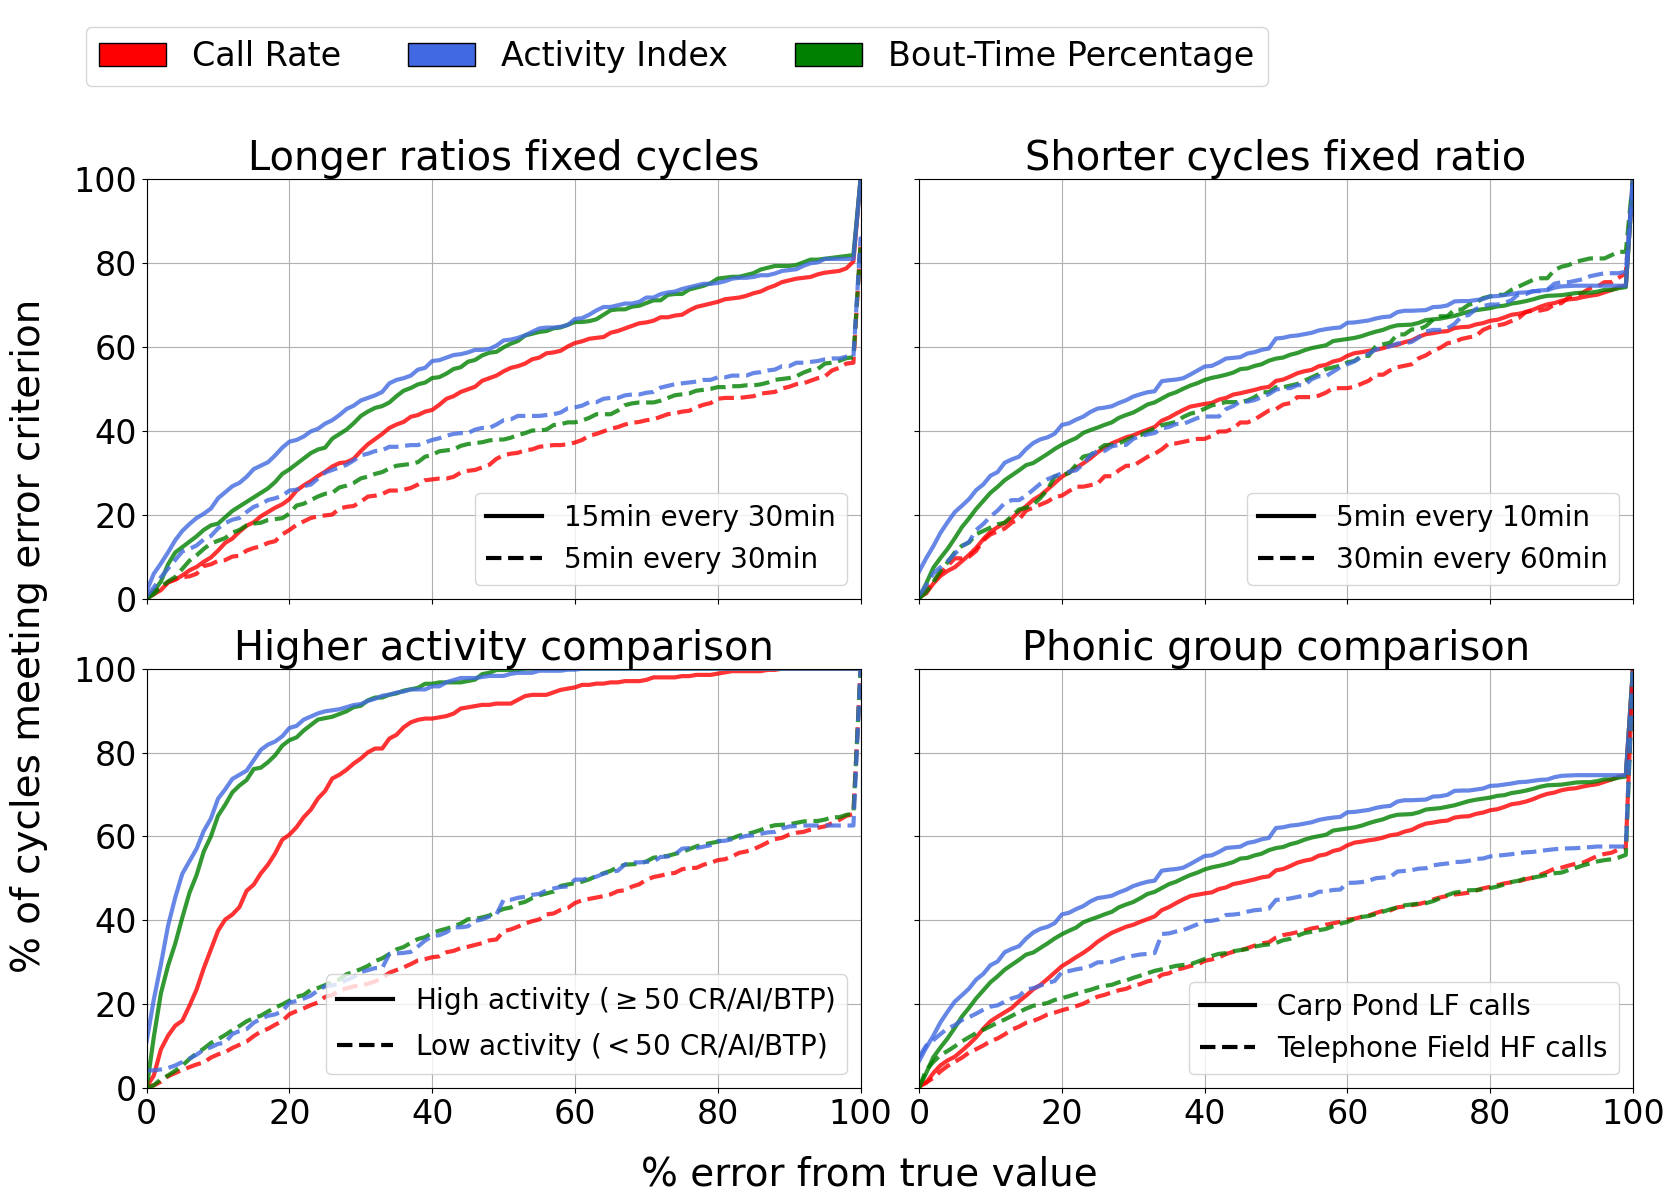

In [17]:
site_key = 'Carp'
actvt_key = 'high'
type_key = activity_types[actvt_key][site_key]
data_params['start'] = dt_starts[f'{site_key} {actvt_key}']
data_params['end'] = dt_ends[f'{site_key} {actvt_key}']
print(site_key, type_key)
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params['detector_tag'] = 'bd2'
data_params['assembly_type'] = 'kmeans'
file_paths = get_file_paths(data_params)
data_params['P'] = 0.20

fig, ax = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True, sharey=True, sharex=True)
plt.rcParams.update({'font.size':24})
ax1, ax2, ax3, ax4 = ax[0,0], ax[0,1], ax[1,0], ax[1,1]

dc1 = '5of30'
dc2 = '15of30'
ax1.set_title(f'Longer ratios fixed cycles')
plot_eval_for_all_metrics_comparing_2_dc(ax1, file_paths, dc1, dc2, data_params)
# create manual symbols for legend
line1 = Line2D([0], [0], linewidth=3, linestyle='solid', label=f'{dc2.split("of")[0]}min every {dc2.split("of")[1]}min', color='k')
line2 = Line2D([0], [0], linewidth=3, linestyle='dashed', label=f'{dc1.split("of")[0]}min every {dc1.split("of")[1]}min', color='k')
ax1.set_xlim(0, 100)
ax1.set_ylim(0, 100)
ax1.set_yticks(np.arange(0, 120, 20))
ax1.legend(handles=[line1, line2], loc='lower right', fontsize=plt.rcParams['font.size']-4)
ax1.grid(which='both')

dc1 = '30of60'
dc2 = '5of10'
ax2.set_title(f'Shorter cycles fixed ratio')
plot_eval_for_all_metrics_comparing_2_dc(ax2, file_paths, dc1, dc2, data_params)
# create manual symbols for legend
line1 = Line2D([0], [0], linewidth=3, linestyle='solid', label=f'{dc2.split("of")[0]}min every {dc2.split("of")[1]}min', color='k')
line2 = Line2D([0], [0], linewidth=3, linestyle='dashed', label=f'{dc1.split("of")[0]}min every {dc1.split("of")[1]}min', color='k')
ax2.legend(handles=[line1, line2], loc='lower right', fontsize=plt.rcParams['font.size']-4)
ax2.grid(which='both')
ax2.set_yticks(np.arange(0, 120, 20))

dc_col = '5of10'
ax3.set_title(f'Higher activity comparison')
plot_dc_scheme_eval_for_all_metrics(ax3, file_paths, dc_col, data_params)
ax3.set_xlim(0, 100)
ax3.set_ylim(0, 100)
ax3.grid(which='both')
# create manual symbols for legend
line1 = Line2D([0], [0], linewidth=3, linestyle='solid', label='High activity ($\geq$50 CR/AI/BTP)', color='k')
line2 = Line2D([0], [0], linewidth=3, linestyle='dashed', label='Low activity ($<$50 CR/AI/BTP)', color='k')
ax3.legend(handles=[line1, line2], loc='lower right', fontsize=plt.rcParams['font.size']-4)

dc_col = '5of10'
site_key = 'Carp'
actvt_key = 'high'
type_key = activity_types[actvt_key][site_key]
data_params['start'] = dt_starts[f'{site_key} {actvt_key}']
data_params['end'] = dt_ends[f'{site_key} {actvt_key}']
print(site_key, type_key)
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params['detector_tag'] = 'bd2'
data_params['assembly_type'] = 'kmeans'
file_paths = get_file_paths(data_params)
p_settings = {'linestyle':'solid', 'linewidth':3}
data_params['P'] = 0.20
line1 = Line2D([0], [0], linewidth=3, linestyle='solid', label=f'{data_params["site_name"]} {type_key} calls', color='k')
plot_all_single_dc_metric_curves(ax4, file_paths, dc_col, data_params, p_settings)

site_key = 'Telephone'
actvt_key = 'high'
type_key = activity_types[actvt_key][site_key]
data_params['start'] = dt_starts[f'{site_key} {actvt_key}']
data_params['end'] = dt_ends[f'{site_key} {actvt_key}']
print(site_key, type_key)
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params['detector_tag'] = 'bd2'
data_params['assembly_type'] = 'kmeans'
file_paths = get_file_paths(data_params)
p_settings['linestyle'] = 'dashed'
line2 = Line2D([0], [0], linewidth=3, linestyle='dashed', label=f'{data_params["site_name"]} {type_key} calls', color='k')
plot_all_single_dc_metric_curves(ax4, file_paths, dc_col, data_params, p_settings)
ax4.set_title('Phonic group comparison')
ax4.set_xlim(0, 100)
ax4.set_ylim(0, 100)
ax4.grid(which='both')
ax4.legend(handles=[line1, line2], loc='lower right', fontsize=plt.rcParams['font.size']-4)

fig.text(-0.025, 0.17, '% of cycles meeting error criterion', ha='center', rotation='vertical', fontsize=plt.rcParams['font.size']+4)
fig.text(0.5, -0.05, '% error from true value', ha='center', fontsize=plt.rcParams['font.size']+4)

# Create legend patches
CR_patch = patches.Patch(facecolor='red', edgecolor='k', label='Call Rate')
AI_patch = patches.Patch(facecolor='royalblue', edgecolor='k', label='Activity Index')
BTP_patch = patches.Patch(facecolor='green', edgecolor='k', label='Bout-Time Percentage')
legend_patches = [CR_patch, AI_patch, BTP_patch]

# Add legend
legend_ax = fig.add_axes([0.0, 0.0, 1.0, 1.125])
legend_ax.axis('off')
legend_ax.legend(handles=legend_patches, fontsize=plt.rcParams['font.size'], ncol=3, loc='upper left')

plt.show()